# Customer Churn Prediction - Advanced LightGBM
## Feature Engineering Completo + Optuna Tuning + Multi-Seed Ensemble

**Optimizado para Apple Silicon M3 con GPU**

### Estrategia:
1. Feature engineering extenso (134+ features) basado en dataset original
2. Optuna hyperparameter tuning optimizado para M3
3. Multi-seed ensemble (4 seeds)
4. Pseudo-labeling en Stage 2
5. Submissions en múltiples etapas

**Tiempo estimado: 4-5 horas**  
**Meta: Superar 0.915 ROC-AUC**

## 1. Imports y Configuración

In [1]:
import os
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Modelo
import lightgbm as lgb
from lightgbm import LGBMClassifier, early_stopping

# Validación
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score

# Tuning
import optuna
from optuna.samplers import TPESampler

# Configuración
plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', None)

# =========================
# Config
# =========================
TRAIN_PATH = "train.csv"
TEST_PATH = "test.csv"
ORIG_PATH = "WA_Fn-UseC_-Telco-Customer-Churn.csv"  # Dataset original

ID_COL = "id"
TARGET = "Churn"

# Cross-validation
N_SPLITS = 5
SEEDS = [11, 42, 99, 202]  # Multi-seed ensemble
BASE_SEED = 42

# Pseudo-labeling
HI = 0.998
LO = 0.002
PSEUDO_W = 0.05

# Target encoding
TE_N_SPLITS = 5
TE_SMOOTH = 20

# Optuna
OPTUNA_TRIALS = 100  # Más trials para mejor búsqueda
OPTUNA_TIMEOUT = 3 * 60 * 60  # 3 horas máximo para tuning

# =========================
# Optimización M3
# =========================
N_CORES = os.cpu_count()
os.environ['OMP_NUM_THREADS'] = str(N_CORES)
os.environ['LIGHTGBM_GPU'] = '0'  # Activar GPU

# Seed
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(BASE_SEED)

print("="*70)
print("ADVANCED CHURN PREDICTION - M3 OPTIMIZADO")
print("="*70)
print(f"✅ Imports completados")
print(f"🍎 Apple Silicon M3 - {N_CORES} cores")
print(f"🔥 LightGBM con GPU activado")
print(f"📊 Optuna tuning: {OPTUNA_TRIALS} trials (max {OPTUNA_TIMEOUT/3600:.1f}h)")
print(f"🎲 Multi-seed ensemble: {len(SEEDS)} seeds")
print(f"🎯 Cross-validation: {N_SPLITS}-fold")
print("="*70)

ADVANCED CHURN PREDICTION - M3 OPTIMIZADO
✅ Imports completados
🍎 Apple Silicon M3 - 8 cores
🔥 LightGBM con GPU activado
📊 Optuna tuning: 100 trials (max 3.0h)
🎲 Multi-seed ensemble: 4 seeds
🎯 Cross-validation: 5-fold


## 2. Feature Engineering - Funciones Utilitarias

In [2]:
# =========================
# Utilities
# =========================
def percentile_rank_from_sorted(sorted_values, x):
    if len(sorted_values) == 0:
        return 0.5
    return np.searchsorted(sorted_values, x, side="right") / len(sorted_values)

def add_percentile_feature(df, col, ref_values, new_col):
    ref_values = np.asarray(ref_values, dtype=float)
    ref_values = ref_values[~np.isnan(ref_values)]
    ref_sorted = np.sort(ref_values)
    df[new_col] = df[col].apply(lambda x: percentile_rank_from_sorted(ref_sorted, x)).astype(float)
    return df

def add_zscore_feature(df, col, ref_values, new_col):
    ref_values = np.asarray(ref_values, dtype=float)
    ref_values = ref_values[~np.isnan(ref_values)]
    mu = ref_values.mean() if len(ref_values) > 0 else 0.0
    sd = ref_values.std() if len(ref_values) > 0 else 1.0
    if sd < 1e-6:
        sd = 1.0
    df[new_col] = ((df[col] - mu) / sd).astype(float)
    return df

print("✅ Funciones utilitarias cargadas")

✅ Funciones utilitarias cargadas


## 3. Feature Engineering Básico

In [3]:
SERVICES = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 
            'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

ADD_SERVICES = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                'TechSupport', 'StreamingTV', 'StreamingMovies']

CONTRACT_MAP = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}

def feature_engineering_basic(df: pd.DataFrame) -> pd.DataFrame:
    """Feature engineering básico + bi-gramas"""
    df = df.copy()
    eps = 1e-3

    # Asegurar tipos numéricos
    for c in ["tenure", "MonthlyCharges", "TotalCharges"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0).astype(float)

    # Numeric interactions
    if all(c in df.columns for c in ["tenure", "MonthlyCharges", "TotalCharges"]):
        df['avg_charge'] = df['TotalCharges'] / (df['tenure'] + 1.0)
        df['charge_diff'] = df['MonthlyCharges'] - df['avg_charge']
        df['TotalCharges_log'] = np.log1p(df['TotalCharges'])
        df['MonthlyCharges_log'] = np.log1p(df['MonthlyCharges'])
        df['tenure_log'] = np.log1p(df['tenure'])
        df['tenure_x_monthly'] = df['tenure'] * df['MonthlyCharges']
        df['charges_per_tenure'] = df['TotalCharges'] / (df['tenure'] + 1)
        df['monthly_to_total_ratio'] = df['MonthlyCharges'] / (df['TotalCharges'] + 1)
        df['price_change_indicator'] = np.where(df['charge_diff'].abs() > 10, 1, 0)

    # Tenure binning
    if "tenure" in df.columns:
        bins = [-1, 0, 1, 3, 6, 12, 24, 36, 48, 60, 72, np.inf]
        df["tenure_bin"] = pd.cut(df["tenure"], bins=bins, labels=False).astype("Int64").astype(str)

    # Service features
    existing_service_cols = [c for c in ADD_SERVICES if c in df.columns]
    if existing_service_cols:
        df["num_services"] = (df[existing_service_cols] == "Yes").sum(axis=1)
        df['num_add_services'] = df[ADD_SERVICES].isin(['Yes']).sum(axis=1)
        df['per_cost'] = df['MonthlyCharges'] / (df['num_services'] + eps)
        df['tenure_per_service'] = df['tenure'] / (df['num_services'] + 1)
        df['service_density'] = df['num_add_services'] / (df['num_services'] + 1)

    # Streaming
    if "StreamingTV" in df.columns and "StreamingMovies" in df.columns:
        df["has_streaming"] = (
            (df["StreamingTV"].astype(str) == "Yes") |
            (df["StreamingMovies"].astype(str) == "Yes")
        ).astype(int)
        df['streaming_bundle'] = (
            (df['StreamingTV'] == 'Yes').astype(int) +
            (df['StreamingMovies'] == 'Yes').astype(int)
        )

    # Contract features
    if "Contract" in df.columns:
        df["contract_num"] = df["Contract"].map(CONTRACT_MAP).fillna(-1).astype(int)
        df['monthly_contract'] = (df['Contract'] == 'Month-to-month').astype(int)
        df['long_contract'] = df['Contract'].isin(['One year', 'Two year']).astype(int)

    if "tenure" in df.columns and "contract_num" in df.columns:
        df["tenure_contract"] = df["tenure"] * df["contract_num"]

    # Payment features
    if "PaymentMethod" in df.columns:
        df["is_auto_payment"] = (
            df["PaymentMethod"].astype(str).str.contains("automatic", case=False, na=False)
        ).astype(int)
        df['is_electronic_check'] = (df['PaymentMethod'] == 'Electronic check').astype(int)

    # Paperless + echeck
    if 'PaperlessBilling' in df.columns and 'PaymentMethod' in df.columns:
        df['paperless_and_echeck'] = (
            (df['PaperlessBilling'] == 'Yes') & (df['PaymentMethod'] == 'Electronic check')
        ).astype(int)

    # Internet service
    if "InternetService" in df.columns:
        df["has_internet"] = (df["InternetService"].astype(str) != "No").astype(int)
        df['has_fiber'] = (df['InternetService'] == 'Fiber optic').astype(int)
        df['has_dsl'] = (df['InternetService'] == 'DSL').astype(int)
        df['no_internet'] = (df['InternetService'] == 'No').astype(int)
        
        if 'MonthlyCharges' in df.columns:
            df['fiber_high_cost'] = ((df['has_fiber'] == 1) & (df['MonthlyCharges'] > 80)).astype(int)

    # Internet + services
    if "InternetService" in df.columns and existing_service_cols:
        df["internet_services"] = (
            (df["InternetService"].astype(str) != "No")
            & (df[existing_service_cols] == "Yes").any(axis=1)
        ).astype(int)
        df['internet_no_protection'] = (
            (df['InternetService'] != 'No') & (df['num_services'] == 0)
        ).astype(int)

    # Customer lifecycle
    if 'tenure' in df.columns:
        df['is_new_customer'] = (df['tenure'] <= 6).astype(int)
        df['is_mid_customer'] = ((df['tenure'] > 6) & (df['tenure'] <= 24)).astype(int)
        df['is_loyal_customer'] = (df['tenure'] > 24).astype(int)
        df['is_very_loyal'] = (df['tenure'] > 48).astype(int)

    # Demographics
    if 'SeniorCitizen' in df.columns and 'Partner' in df.columns:
        df['senior_no_partner'] = ((df['SeniorCitizen'] == 1) & (df['Partner'] == 'No')).astype(int)
    if 'SeniorCitizen' in df.columns and 'Dependents' in df.columns:
        df['senior_no_dependents'] = ((df['SeniorCitizen'] == 1) & (df['Dependents'] == 'No')).astype(int)
    if 'Partner' in df.columns and 'Dependents' in df.columns:
        df['single_household'] = ((df['Partner'] == 'No') & (df['Dependents'] == 'No')).astype(int)

    # Security bundle
    if all(c in df.columns for c in ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']):
        df['security_bundle'] = (
            (df['OnlineSecurity'] == 'Yes').astype(int) +
            (df['OnlineBackup'] == 'Yes').astype(int) +
            (df['DeviceProtection'] == 'Yes').astype(int) +
            (df['TechSupport'] == 'Yes').astype(int)
        )

    # Binning adicional
    if 'MonthlyCharges' in df.columns:
        df['monthlycharges_bin'] = pd.cut(
            df['MonthlyCharges'], bins=[-np.inf, 35, 70, 100, np.inf],
            labels=['low', 'mid', 'high', 'very_high']
        ).astype(str)
    
    if 'TotalCharges' in df.columns:
        df['totalcharges_bin'] = pd.cut(
            df['TotalCharges'], bins=[-np.inf, 500, 1500, 3000, np.inf],
            labels=['very_low', 'low', 'mid', 'high']
        ).astype(str)

    # Bi-grams (interacciones categóricas)
    bigram_pairs = [
        ("Contract", "PaymentMethod"),
        ("Contract", "InternetService"),
        ("InternetService", "OnlineSecurity"),
        ("InternetService", "TechSupport"),
        ("PaymentMethod", "PaperlessBilling"),
        ("InternetService", "StreamingTV"),
        ("InternetService", "StreamingMovies"),
        ("Contract", "TechSupport"),
    ]

    for c1, c2 in bigram_pairs:
        if c1 in df.columns and c2 in df.columns:
            df[f"{c1}_x_{c2}"] = df[c1].astype(str) + "__" + df[c2].astype(str)

    # Categorical crosses adicionales
    if 'gender' in df.columns and 'SeniorCitizen' in df.columns:
        df['gender_senior'] = df['gender'].astype(str) + '_' + df['SeniorCitizen'].astype(str)
    if 'Partner' in df.columns and 'Dependents' in df.columns:
        df['partner_dependents'] = df['Partner'].astype(str) + '_' + df['Dependents'].astype(str)
    if 'InternetService' in df.columns and 'PaymentMethod' in df.columns:
        df['internet_payment'] = df['InternetService'].astype(str) + '_' + df['PaymentMethod'].astype(str)

    # Risk score
    risk_score = 0
    if 'monthly_contract' in df.columns:
        risk_score += df['monthly_contract'] * 3
    if 'is_electronic_check' in df.columns:
        risk_score += df['is_electronic_check'] * 2
    if 'is_new_customer' in df.columns:
        risk_score += df['is_new_customer'] * 2
    if 'has_fiber' in df.columns:
        risk_score += df['has_fiber'] * 1
    if 'paperless_and_echeck' in df.columns:
        risk_score += df['paperless_and_echeck'] * 2
    if 'single_household' in df.columns:
        risk_score += df['single_household'] * 1
    if 'long_contract' in df.columns:
        risk_score -= df['long_contract'] * 2
    if 'is_auto_payment' in df.columns:
        risk_score -= df['is_auto_payment'] * 1
    if 'is_loyal_customer' in df.columns:
        risk_score -= df['is_loyal_customer'] * 2
    df['churn_risk_score'] = risk_score

    return df

print("✅ Feature engineering básico definido")

✅ Feature engineering básico definido


## 4. Feature Engineering Basado en Dataset Original

In [4]:
# =========================
# Original-based features
# =========================
def add_orig_proba_features(df, orig, cat_cols_for_orig):
    """Probabilidades de churn basadas en dataset original"""
    df = df.copy()
    global_mean = orig[TARGET].mean()

    for col in cat_cols_for_orig:
        if col not in df.columns or col not in orig.columns:
            continue
        stats = orig.groupby(col, dropna=False)[TARGET].mean()
        df[f"ORIG_proba_{col}"] = df[col].map(stats).fillna(global_mean).astype(float)

    return df

def add_orig_binned_proba_features(df, orig, num_bin_cols):
    """Probabilidades de churn basadas en bins numéricos del original"""
    df = df.copy()
    orig = orig.copy()
    global_mean = orig[TARGET].mean()

    for col, bins in num_bin_cols.items():
        if col not in df.columns or col not in orig.columns:
            continue

        bin_col = f"{col}_orig_bin"
        df[bin_col] = pd.cut(df[col], bins=bins, labels=False, include_lowest=True).astype("Int64").astype(str)
        orig[bin_col] = pd.cut(orig[col], bins=bins, labels=False, include_lowest=True).astype("Int64").astype(str)

        stats = orig.groupby(bin_col, dropna=False)[TARGET].mean()
        df[f"ORIG_proba_{bin_col}"] = df[bin_col].map(stats).fillna(global_mean).astype(float)

    return df

def add_distribution_position_features(df, orig):
    """Features de posición en distribución (percentiles, z-scores)"""
    df = df.copy()

    target_num_cols = ["TotalCharges", "MonthlyCharges", "tenure"]
    orig_ch = orig[orig[TARGET] == 1]
    orig_nc = orig[orig[TARGET] == 0]

    for col in target_num_cols:
        if col not in df.columns or col not in orig.columns:
            continue

        # Percentiles
        df = add_percentile_feature(df, col, orig[col].values, f"{col}_pct_orig")
        df = add_percentile_feature(df, col, orig_ch[col].values, f"{col}_pct_churn")
        df = add_percentile_feature(df, col, orig_nc[col].values, f"{col}_pct_nonchurn")
        df[f"{col}_pct_gap"] = df[f"{col}_pct_churn"] - df[f"{col}_pct_nonchurn"]

        # Z-scores
        df = add_zscore_feature(df, col, orig[col].values, f"{col}_z_orig")
        df = add_zscore_feature(df, col, orig_ch[col].values, f"{col}_z_churn")
        df = add_zscore_feature(df, col, orig_nc[col].values, f"{col}_z_nonchurn")
        df[f"{col}_z_gap"] = np.abs(df[f"{col}_z_nonchurn"]) - np.abs(df[f"{col}_z_churn"])

    # Conditional percentile for TotalCharges
    for group_col in ["InternetService", "Contract"]:
        if group_col in df.columns and group_col in orig.columns and "TotalCharges" in df.columns:
            vals = []
            for _, row in df[[group_col, "TotalCharges"]].iterrows():
                ref = orig.loc[orig[group_col] == row[group_col], "TotalCharges"].values
                vals.append(percentile_rank_from_sorted(np.sort(ref), row["TotalCharges"]))
            df[f"TotalCharges_pct_by_{group_col}"] = np.array(vals, dtype=float)

    # MonthlyCharges residual by InternetService
    if "MonthlyCharges" in df.columns and "InternetService" in df.columns:
        mean_by_is = orig.groupby("InternetService")["MonthlyCharges"].mean()
        global_mc = orig["MonthlyCharges"].mean()
        ref_mean = df["InternetService"].map(mean_by_is).fillna(global_mc)
        df["MonthlyCharges_resid_by_InternetService"] = df["MonthlyCharges"] - ref_mean

    return df

def add_quantile_distance_features(df, orig):
    """Distancias a cuantiles de distribuciones de churn/no-churn"""
    df = df.copy()

    target_num_cols = ["TotalCharges", "MonthlyCharges", "tenure"]
    quantiles = [0.25, 0.50, 0.75]

    orig_ch = orig[orig[TARGET] == 1]
    orig_nc = orig[orig[TARGET] == 0]

    for col in target_num_cols:
        if col not in df.columns or col not in orig.columns:
            continue

        for q in quantiles:
            qname = int(q * 100)

            ch_q = orig_ch[col].quantile(q)
            nc_q = orig_nc[col].quantile(q)

            df[f"{col}_dist_churn_q{qname}"] = np.abs(df[col] - ch_q)
            df[f"{col}_dist_nonchurn_q{qname}"] = np.abs(df[col] - nc_q)
            df[f"{col}_dist_gap_q{qname}"] = (
                df[f"{col}_dist_nonchurn_q{qname}"] - df[f"{col}_dist_churn_q{qname}"]
            )

    return df

def add_conditional_q50_distance_features(df, orig):
    """Distancias a medianas condicionales por categoría"""
    df = df.copy()

    # 1) TotalCharges by InternetService
    if "TotalCharges" in df.columns and "InternetService" in df.columns:
        median_by_is_tc = orig.groupby("InternetService")["TotalCharges"].median()
        global_tc_med = orig["TotalCharges"].median()
        ref = df["InternetService"].map(median_by_is_tc).fillna(global_tc_med)
        df["TotalCharges_dist_by_InternetService_q50"] = np.abs(df["TotalCharges"] - ref)

    # 2) TotalCharges by Contract
    if "TotalCharges" in df.columns and "Contract" in df.columns:
        median_by_contract_tc = orig.groupby("Contract")["TotalCharges"].median()
        global_tc_med = orig["TotalCharges"].median()
        ref = df["Contract"].map(median_by_contract_tc).fillna(global_tc_med)
        df["TotalCharges_dist_by_Contract_q50"] = np.abs(df["TotalCharges"] - ref)

    # 3) MonthlyCharges by InternetService
    if "MonthlyCharges" in df.columns and "InternetService" in df.columns:
        median_by_is_mc = orig.groupby("InternetService")["MonthlyCharges"].median()
        global_mc_med = orig["MonthlyCharges"].median()
        ref = df["InternetService"].map(median_by_is_mc).fillna(global_mc_med)
        df["MonthlyCharges_dist_by_InternetService_q50"] = np.abs(df["MonthlyCharges"] - ref)

    # 4) MonthlyCharges by Contract
    if "MonthlyCharges" in df.columns and "Contract" in df.columns:
        med = orig.groupby("Contract")["MonthlyCharges"].median()
        global_med = orig["MonthlyCharges"].median()
        ref = df["Contract"].map(med).fillna(global_med)
        df["MonthlyCharges_dist_by_Contract_q50"] = np.abs(df["MonthlyCharges"] - ref)

    # 5) tenure by InternetService
    if "tenure" in df.columns and "InternetService" in df.columns:
        med = orig.groupby("InternetService")["tenure"].median()
        global_med = orig["tenure"].median()
        ref = df["InternetService"].map(med).fillna(global_med)
        df["tenure_dist_by_InternetService_q50"] = np.abs(df["tenure"] - ref)

    # 6) tenure by Contract
    if "tenure" in df.columns and "Contract" in df.columns:
        med = orig.groupby("Contract")["tenure"].median()
        global_med = orig["tenure"].median()
        ref = df["Contract"].map(med).fillna(global_med)
        df["tenure_dist_by_Contract_q50"] = np.abs(df["tenure"] - ref)

    return df
    
def add_frequency_features(train_df, test_df, orig_df, cols):
    """Features de frecuencia combinando datasets"""
    train_df = train_df.copy()
    test_df = test_df.copy()

    all_df = pd.concat(
        [train_df[cols].copy(), test_df[cols].copy(), orig_df[cols].copy()],
        axis=0,
        ignore_index=True,
    )

    for col in cols:
        freq = all_df[col].value_counts(dropna=False)
        train_df[f"{col}_freq"] = train_df[col].map(freq).fillna(0).astype(float)
        test_df[f"{col}_freq"] = test_df[col].map(freq).fillna(0).astype(float)

    return train_df, test_df

print("✅ Feature engineering basado en dataset original definido")

✅ Feature engineering basado en dataset original definido


## 5. Out-of-Fold Target Encoding

In [5]:
# =========================
# OOF Target Encoding
# =========================
def make_te_mapping(series, y, smoothing=20):
    tmp = pd.DataFrame({"col": series.astype(str), "y": y})
    global_mean = tmp["y"].mean()
    stats = tmp.groupby("col")["y"].agg(["mean", "count", "std"])
    stats["std"] = stats["std"].fillna(0.0)

    stats["mean_smooth"] = (
        stats["count"] * stats["mean"] + smoothing * global_mean
    ) / (stats["count"] + smoothing)

    return stats[["mean_smooth", "std"]], global_mean

def add_oof_te_features(train_df, test_df, y, te_cols, n_splits=5, seed=42, smoothing=20):
    train_df = train_df.copy()
    test_df = test_df.copy()

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

    for col in te_cols:
        train_df[f"{col}_te_mean"] = np.nan
        train_df[f"{col}_te_std"] = np.nan

        for tr_idx, va_idx in skf.split(train_df, y):
            tr_x = train_df.iloc[tr_idx]
            va_x = train_df.iloc[va_idx]
            y_tr = y[tr_idx]

            stats, global_mean = make_te_mapping(tr_x[col], y_tr, smoothing=smoothing)

            va_key = va_x[col].astype(str)
            train_df.loc[va_x.index, f"{col}_te_mean"] = va_key.map(stats["mean_smooth"]).fillna(global_mean).values
            train_df.loc[va_x.index, f"{col}_te_std"] = va_key.map(stats["std"]).fillna(0.0).values

        # full mapping for test
        full_stats, full_global_mean = make_te_mapping(train_df[col], y, smoothing=smoothing)
        test_key = test_df[col].astype(str)

        test_df[f"{col}_te_mean"] = test_key.map(full_stats["mean_smooth"]).fillna(full_global_mean).values
        test_df[f"{col}_te_std"] = test_key.map(full_stats["std"]).fillna(0.0).values

    return train_df, test_df

print("✅ Target encoding OOF definido")

✅ Target encoding OOF definido


In [6]:
# =========================
# LightGBM category helper
# =========================
def prepare_lgb_data(X_tr, X_va, X_te, cat_cols):
    X_tr = X_tr.copy()
    X_va = X_va.copy()
    X_te = X_te.copy()

    for c in cat_cols:
        X_tr[c] = X_tr[c].astype("category")
        X_va[c] = X_va[c].astype("category")
        X_te[c] = X_te[c].astype("category")

        all_cats = (
            pd.Index(X_tr[c].cat.categories)
            .union(pd.Index(X_va[c].cat.categories))
            .union(pd.Index(X_te[c].cat.categories))
        )
        X_tr[c] = X_tr[c].cat.set_categories(all_cats)
        X_va[c] = X_va[c].cat.set_categories(all_cats)
        X_te[c] = X_te[c].cat.set_categories(all_cats)

    return X_tr, X_va, X_te

print("✅ Helper para LightGBM categorías definido")

✅ Helper para LightGBM categorías definido


## 6. Carga y Preparación de Datos

In [7]:
print("="*70)
print("CARGANDO DATOS")
print("="*70)

# =========================
# Load data
# =========================
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

# Intentar cargar dataset original
try:
    orig = pd.read_csv(ORIG_PATH)
    print(f"✅ Dataset original cargado: {orig.shape}")
except FileNotFoundError:
    print(f"⚠️  Dataset original no encontrado en {ORIG_PATH}")
    print(f"⚠️  Usando subset de train como referencia...")
    # Fallback: crear orig vacío
    orig = train.sample(n=min(7043, len(train)), random_state=BASE_SEED).copy()
    if ID_COL in orig.columns:
        orig = orig.drop(columns=[ID_COL])
    print(f"✅ Usando subset de train como referencia: {orig.shape}")

# Limpiar dataset original
orig = orig.drop(columns=["customerID"], errors="ignore")
if ID_COL in orig.columns:
    orig = orig.drop(columns=[ID_COL], errors="ignore")

# Convertir target
train[TARGET] = train[TARGET].map({"No": 0, "Yes": 1}).astype(int)
orig[TARGET] = orig[TARGET].map({"No": 0, "Yes": 1}).astype(int)

y_train = train[TARGET].values

print(f"✅ Train: {train.shape}")
print(f"✅ Test: {test.shape}")
print(f"✅ Original: {orig.shape}")
print(f"✅ Churn rate train: {y_train.mean():.4f}")
print(f"✅ Churn rate original: {orig[TARGET].mean():.4f}")

CARGANDO DATOS
✅ Dataset original cargado: (7043, 21)
✅ Train: (594194, 21)
✅ Test: (254655, 20)
✅ Original: (7043, 20)
✅ Churn rate train: 0.2252
✅ Churn rate original: 0.2654


In [8]:
print("\n" + "="*70)
print("FEATURE ENGINEERING COMPLETO")
print("="*70)

# Guardar IDs
test_ids = test[ID_COL].copy()

# Base FE
print("📊 Aplicando feature engineering básico...")
X_train = feature_engineering_basic(train.drop(columns=[ID_COL, TARGET]))
X_test = feature_engineering_basic(test.drop(columns=[ID_COL]))
orig_X = feature_engineering_basic(orig.drop(columns=[TARGET]))

# Alinear columnas
print("📊 Alineando columnas...")
for c in X_train.columns:
    if c not in X_test.columns:
        X_test[c] = np.nan
    if c not in orig_X.columns:
        orig_X[c] = np.nan

X_test = X_test[X_train.columns]
orig_X = orig_X[X_train.columns]

orig_feat = orig_X.copy()
orig_feat[TARGET] = orig[TARGET].values

print(f"✅ Features básicas: {X_train.shape[1]} columnas")

# =========================
# Add original-based features
# =========================
print("\n📊 Agregando features basadas en dataset original...")

orig_cat_cols = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "OnlineSecurity",
    "TechSupport",
    "PaperlessBilling",
    "tenure_bin",
    # bi-grams
    "Contract_x_PaymentMethod",
    "Contract_x_InternetService",
    "InternetService_x_OnlineSecurity",
    "InternetService_x_TechSupport",
]

X_train = add_orig_proba_features(X_train, orig_feat, orig_cat_cols)
X_test = add_orig_proba_features(X_test, orig_feat, orig_cat_cols)
print(f"✅ Probabilidades de churn agregadas para {len(orig_cat_cols)} categorías")

num_bin_cols = {
    "tenure": [-1, 0, 1, 3, 6, 12, 24, 36, 48, 60, 72, np.inf],
    "MonthlyCharges": [-np.inf, 20, 40, 60, 80, 100, 120, np.inf],
    "TotalCharges": [-np.inf, 100, 500, 1000, 2000, 4000, 6000, np.inf],
}
X_train = add_orig_binned_proba_features(X_train, orig_feat, num_bin_cols)
X_test = add_orig_binned_proba_features(X_test, orig_feat, num_bin_cols)
print(f"✅ Probabilidades de churn en bins numéricos agregadas")

print("📊 Agregando features de posición en distribución...")
X_train = add_distribution_position_features(X_train, orig_feat)
X_test = add_distribution_position_features(X_test, orig_feat)
print(f"✅ Features de percentiles y z-scores agregadas")

print("📊 Agregando features de distancia a cuantiles...")
X_train = add_quantile_distance_features(X_train, orig_feat)
X_test = add_quantile_distance_features(X_test, orig_feat)
print(f"✅ Features de distancia a Q25, Q50, Q75 agregadas")

print("📊 Agregando features de distancia condicional...")
X_train = add_conditional_q50_distance_features(X_train, orig_feat)
X_test = add_conditional_q50_distance_features(X_test, orig_feat)
print(f"✅ Features de medianas condicionales agregadas")

print("📊 Agregando features de frecuencia...")
X_train, X_test = add_frequency_features(
    X_train, X_test, orig_X, ["tenure", "MonthlyCharges", "TotalCharges"]
)
print(f"✅ Features de frecuencia agregadas")

print(f"\n✅ Total features después de original-based: {X_train.shape[1]} columnas")


FEATURE ENGINEERING COMPLETO
📊 Aplicando feature engineering básico...
📊 Alineando columnas...
✅ Features básicas: 72 columnas

📊 Agregando features basadas en dataset original...
✅ Probabilidades de churn agregadas para 11 categorías
✅ Probabilidades de churn en bins numéricos agregadas
📊 Agregando features de posición en distribución...
✅ Features de percentiles y z-scores agregadas
📊 Agregando features de distancia a cuantiles...
✅ Features de distancia a Q25, Q50, Q75 agregadas
📊 Agregando features de distancia condicional...
✅ Features de medianas condicionales agregadas
📊 Agregando features de frecuencia...
✅ Features de frecuencia agregadas

✅ Total features después de original-based: 152 columnas


In [9]:
# =========================
# Add OOF Target Encoding
# =========================
print("\n📊 Agregando Out-of-Fold Target Encoding...")

te_cols = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    # bi-grams
    "Contract_x_InternetService",
    "Contract_x_PaymentMethod",
    "InternetService_x_OnlineSecurity",
    "InternetService_x_TechSupport",
]

# Verificar que existan
te_cols = [c for c in te_cols if c in X_train.columns]
print(f"   Aplicando TE a {len(te_cols)} columnas")

X_train, X_test = add_oof_te_features(
    X_train, X_test, y_train,
    te_cols=te_cols,
    n_splits=TE_N_SPLITS,
    seed=BASE_SEED,
    smoothing=TE_SMOOTH
)

print(f"✅ Target encoding completado: {len(te_cols)} columnas × 2 features = {len(te_cols)*2} nuevas")

# Final align
for c in X_train.columns:
    if c not in X_test.columns:
        X_test[c] = np.nan
X_test = X_test[X_train.columns]

cat_cols = [c for c in X_train.columns if X_train[c].dtype == "object"]

print("\n" + "="*70)
print("RESUMEN DE FEATURES")
print("="*70)
print(f"✅ Shape final - Train: {X_train.shape}")
print(f"✅ Shape final - Test:  {X_test.shape}")
print(f"✅ Columnas categóricas: {len(cat_cols)}")
print(f"✅ Columnas numéricas:   {X_train.shape[1] - len(cat_cols)}")
print(f"✅ Total features:       {X_train.shape[1]}")
print("="*70)


📊 Agregando Out-of-Fold Target Encoding...
   Aplicando TE a 7 columnas
✅ Target encoding completado: 7 columnas × 2 features = 14 nuevas

RESUMEN DE FEATURES
✅ Shape final - Train: (594194, 166)
✅ Shape final - Test:  (254655, 166)
✅ Columnas categóricas: 32
✅ Columnas numéricas:   134
✅ Total features:       166


## 7. Optuna Hyperparameter Tuning (Optimizado M3)

In [10]:
# Crear subset para tuning (15% del dataset para balance velocidad/calidad)
print("\n📊 Creando subset para Optuna tuning...")
X_tune, _, y_tune, _ = train_test_split(
    X_train, y_train, test_size=0.85, random_state=BASE_SEED, stratify=y_train
)

print(f"✅ Dataset para tuning: {X_tune.shape}")
print(f"   Esto hará el tuning ~6x más rápido")
print(f"   Churn rate: {y_tune.mean():.4f}")


📊 Creando subset para Optuna tuning...
✅ Dataset para tuning: (89129, 166)
   Esto hará el tuning ~6x más rápido
   Churn rate: 0.2252


In [11]:
def objective_lightgbm_m3(trial):
    params = {
        # Número de árboles y learning rate
        'n_estimators': trial.suggest_int('n_estimators', 500, 3000, step=250),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.08, log=True),

        # Estructura del árbol
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'min_child_weight': trial.suggest_float('min_child_weight', 1e-4, 50, log=True),

        # Sampling
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'subsample_freq': trial.suggest_int('subsample_freq', 1, 7),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),

        # Regularización
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),

        # Parámetros específicos de LightGBM
        'min_split_gain': trial.suggest_float('min_split_gain', 0.0, 1.0),
        'max_bin': trial.suggest_categorical('max_bin', [255, 511]),

        # Fijos para M3
        'objective': 'binary',
        'metric': 'auc',
        'random_state': BASE_SEED,
        'verbosity': -1,
        'device': 'cpu',  # M3 optimizado con CPU
        'num_threads': N_CORES,
        'force_col_wise': True
    }

    # 3-Fold CV para tuning (equilibrio velocidad/calidad)
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=BASE_SEED)
    scores = []

    for train_idx, val_idx in skf.split(X_tune, y_tune):
        X_tr, X_val = X_tune.iloc[train_idx], X_tune.iloc[val_idx]
        y_tr, y_val = y_tune[train_idx], y_tune[val_idx]

        # Preparar categorías
        X_tr_lgb, X_val_lgb, X_te_dummy = prepare_lgb_data(
            X_tr, X_val, X_test.iloc[:100], cat_cols
        )

        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_tr_lgb, y_tr,
            eval_set=[(X_val_lgb, y_val)],
            callbacks=[lgb.early_stopping(150, verbose=False)],
            categorical_feature=cat_cols
        )

        y_pred = model.predict_proba(X_val_lgb)[:, 1]
        score = roc_auc_score(y_val, y_pred)
        scores.append(score)

    return np.mean(scores)

print("✅ Función objetivo de Optuna definida (optimizada para M3)")

✅ Función objetivo de Optuna definida (optimizada para M3)


In [12]:
print("\n" + "="*70)
print("INICIANDO OPTUNA HYPERPARAMETER TUNING")
print("="*70)
print(f"🔥 Trials: {OPTUNA_TRIALS}")
print(f"⏱️  Timeout: {OPTUNA_TIMEOUT/3600:.1f} horas")
print(f"🍎 Optimizado para M3 con {N_CORES} cores")
print("="*70)
print("\nEsto tomará entre 1.5-3 horas dependiendo de la complejidad...")
print("\n")

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=BASE_SEED)
)

start_time = time.time()
study.optimize(
    objective_lightgbm_m3,
    n_trials=OPTUNA_TRIALS,
    timeout=OPTUNA_TIMEOUT,
    show_progress_bar=True
)
optuna_time = time.time() - start_time

print(f"\n{'='*70}")
print("RESULTADOS DE OPTUNA")
print(f"{'='*70}")
print(f"✅ Mejor ROC-AUC: {study.best_value:.6f}")
print(f"⏱️  Tiempo: {optuna_time/60:.1f} minutos ({optuna_time/3600:.2f} horas)")
print(f"📊 Trials completados: {len(study.trials)}")
print(f"\n🎯 Mejores hiperparámetros:")
for key, value in study.best_params.items():
    if isinstance(value, float):
        print(f"  {key:25s}: {value:.6f}")
    else:
        print(f"  {key:25s}: {value}")
print(f"{'='*70}")

best_params = study.best_params


INICIANDO OPTUNA HYPERPARAMETER TUNING
🔥 Trials: 100
⏱️  Timeout: 3.0 horas
🍎 Optimizado para M3 con 8 cores

Esto tomará entre 1.5-3 horas dependiendo de la complejidad...




Best trial: 43. Best value: 0.914291: 100%|██████████| 100/100 [42:57<00:00, 25.77s/it, 2577.30/10800 seconds]


RESULTADOS DE OPTUNA
✅ Mejor ROC-AUC: 0.914291
⏱️  Tiempo: 43.0 minutos (0.72 horas)
📊 Trials completados: 100

🎯 Mejores hiperparámetros:
  n_estimators             : 2000
  learning_rate            : 0.022104
  max_depth                : 3
  num_leaves               : 115
  min_child_samples        : 28
  min_child_weight         : 1.612126
  subsample                : 0.718347
  subsample_freq           : 1
  colsample_bytree         : 0.692562
  reg_alpha                : 2.417667
  reg_lambda               : 0.133401
  min_split_gain           : 0.854616
  max_bin                  : 511


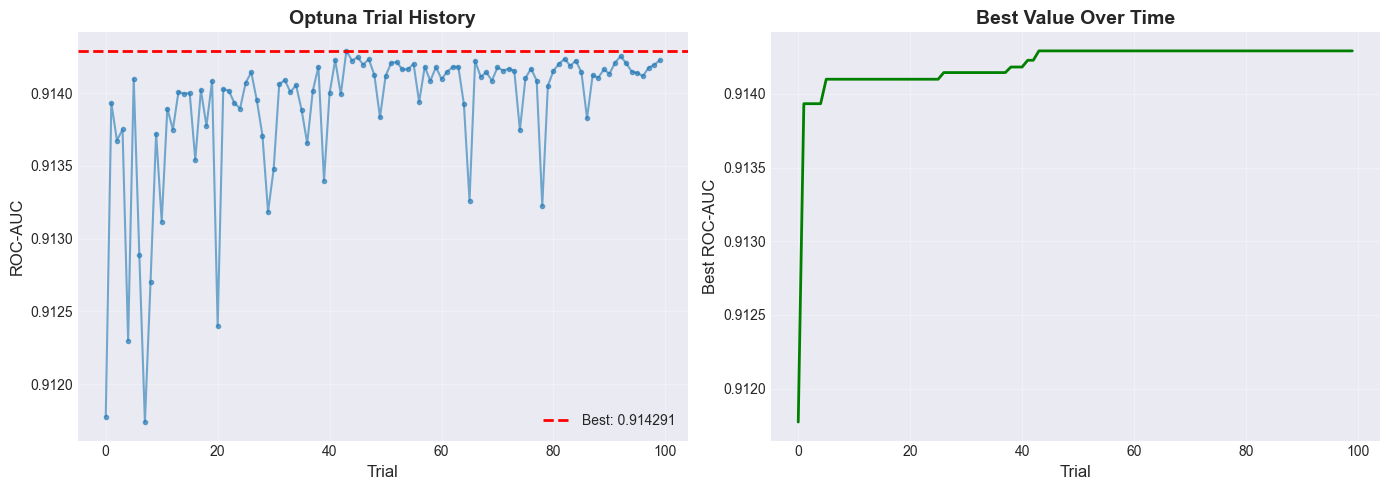

✅ Gráfico guardado: optuna_history_advanced.png


In [13]:
# Historia de optimización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trial history
trial_values = [trial.value for trial in study.trials if trial.value is not None]
axes[0].plot(trial_values, marker='o', markersize=3, alpha=0.6)
axes[0].axhline(y=study.best_value, color='r', linestyle='--', linewidth=2,
                label=f'Best: {study.best_value:.6f}')
axes[0].set_xlabel('Trial', fontsize=12)
axes[0].set_ylabel('ROC-AUC', fontsize=12)
axes[0].set_title('Optuna Trial History', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Best value over time
best_values = [max(trial_values[:i+1]) for i in range(len(trial_values))]
axes[1].plot(best_values, color='green', linewidth=2)
axes[1].set_xlabel('Trial', fontsize=12)
axes[1].set_ylabel('Best ROC-AUC', fontsize=12)
axes[1].set_title('Best Value Over Time', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('optuna_history_advanced.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Gráfico guardado: optuna_history_advanced.png")

## 8. Stage 1: Multi-Seed Training (Sin Pseudo-Labels)

In [14]:
# Preparar parámetros finales
lgb_params = {
    **best_params,
    'objective': 'binary',
    'metric': 'auc',
    'verbosity': -1,
    'device': 'cpu',
    'num_threads': N_CORES,
    'force_col_wise': True
}

print("\n" + "="*70)
print("STAGE 1: MULTI-SEED ENSEMBLE TRAINING")
print("="*70)
print(f"🎲 Seeds: {SEEDS}")
print(f"🎯 Folds: {N_SPLITS}")
print(f"📊 Total modelos: {len(SEEDS)} × {N_SPLITS} = {len(SEEDS) * N_SPLITS}")
print("="*70)
print("\nEsto tomará aproximadamente 1-2 horas...")
print("\n")

oof_lgb = np.zeros(len(X_train))
pred_lgb = np.zeros(len(X_test))

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=BASE_SEED)
all_fold_scores = []

stage1_start = time.time()

for seed_idx, seed in enumerate(SEEDS, 1):
    print(f"\n{'='*70}")
    print(f"SEED {seed_idx}/{len(SEEDS)}: {seed}")
    print(f"{'='*70}")

    oof_lgb_seed = np.zeros(len(X_train))
    pred_lgb_seed = np.zeros(len(X_test))

    lgb_params_seed = lgb_params.copy()
    lgb_params_seed['random_state'] = seed

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train, y_train), 1):
        fold_start = time.time()
        print(f"\n  Fold {fold}/{N_SPLITS} | Seed {seed}")
        print(f"  {'-'*50}")

        X_tr = X_train.iloc[tr_idx].copy()
        X_va = X_train.iloc[va_idx].copy()
        y_tr = y_train[tr_idx]
        y_val = y_train[va_idx]

        # Preparar categorías
        X_tr_lgb, X_va_lgb, X_te_lgb = prepare_lgb_data(X_tr, X_va, X_test, cat_cols)

        # Entrenar
        dtr = lgb.Dataset(X_tr_lgb, label=y_tr, categorical_feature=cat_cols, free_raw_data=False)
        dva = lgb.Dataset(X_va_lgb, label=y_val, categorical_feature=cat_cols, free_raw_data=False)

        model_lgb = lgb.train(
            lgb_params_seed,
            dtr,
            num_boost_round=10000,
            valid_sets=[dva],
            callbacks=[lgb.early_stopping(500, verbose=False)],
        )

        # Predicciones
        va_pred = model_lgb.predict(X_va_lgb, num_iteration=model_lgb.best_iteration)
        te_pred = model_lgb.predict(X_te_lgb, num_iteration=model_lgb.best_iteration)

        oof_lgb_seed[va_idx] = va_pred
        pred_lgb_seed += te_pred / N_SPLITS

        fold_auc = roc_auc_score(y_val, va_pred)
        all_fold_scores.append(fold_auc)
        fold_time = time.time() - fold_start

        print(f"  ROC-AUC: {fold_auc:.6f} | Iter: {model_lgb.best_iteration} | Time: {fold_time:.1f}s")

    seed_auc = roc_auc_score(y_train, oof_lgb_seed)
    print(f"\n  ✅ Seed {seed} CV AUC: {seed_auc:.6f}")

    oof_lgb += oof_lgb_seed / len(SEEDS)
    pred_lgb += pred_lgb_seed / len(SEEDS)

stage1_time = time.time() - stage1_start

cv_auc = roc_auc_score(y_train, oof_lgb)
print(f"\n{'='*70}")
print("STAGE 1 COMPLETADO")
print(f"{'='*70}")
print(f"✅ Multi-Seed OOF AUC: {cv_auc:.6f}")
print(f"📊 Fold AUC - Mean: {np.mean(all_fold_scores):.6f} ± {np.std(all_fold_scores):.6f}")
print(f"⏱️  Tiempo: {stage1_time/60:.1f} min ({stage1_time/3600:.2f}h)")
print(f"{'='*70}")

# Guardar submission Stage 1
submission_stage1 = pd.DataFrame({
    ID_COL: test_ids,
    TARGET: pred_lgb
})
submission_stage1.to_csv('submission_stage1_multiseed.csv', index=False)
print(f"\n💾 Guardado: submission_stage1_multiseed.csv (OOF AUC: {cv_auc:.6f})")


STAGE 1: MULTI-SEED ENSEMBLE TRAINING
🎲 Seeds: [11, 42, 99, 202]
🎯 Folds: 5
📊 Total modelos: 4 × 5 = 20

Esto tomará aproximadamente 1-2 horas...



SEED 1/4: 11

  Fold 1/5 | Seed 11
  --------------------------------------------------
  ROC-AUC: 0.916624 | Iter: 1999 | Time: 269.5s

  Fold 2/5 | Seed 11
  --------------------------------------------------
  ROC-AUC: 0.917338 | Iter: 2000 | Time: 255.5s

  Fold 3/5 | Seed 11
  --------------------------------------------------
  ROC-AUC: 0.916768 | Iter: 2000 | Time: 50.4s

  Fold 4/5 | Seed 11
  --------------------------------------------------
  ROC-AUC: 0.918060 | Iter: 2000 | Time: 55.3s

  Fold 5/5 | Seed 11
  --------------------------------------------------
  ROC-AUC: 0.915137 | Iter: 2000 | Time: 81.4s

  ✅ Seed 11 CV AUC: 0.916778

SEED 2/4: 42

  Fold 1/5 | Seed 42
  --------------------------------------------------
  ROC-AUC: 0.916624 | Iter: 2000 | Time: 76.4s

  Fold 2/5 | Seed 42
  -----------------------------------

## 9. Stage 2: Pseudo-Labeling + Re-training

In [15]:
print("\n" + "="*70)
print("PSEUDO-LABELING")
print("="*70)

# Identificar pseudo-labels de alta confianza
pseudo_mask = (pred_lgb >= HI) | (pred_lgb <= LO)
pseudo_y = (pred_lgb[pseudo_mask] >= 0.5).astype(int)
pseudo_X = X_test.iloc[pseudo_mask].copy()

print(f"✅ Threshold alto (Churn=1): {HI}")
print(f"✅ Threshold bajo (Churn=0):  {LO}")
print(f"✅ Peso pseudo-labels:        {PSEUDO_W}")
print(f"\n📊 Pseudo-labels identificados:")
print(f"   Total: {pseudo_mask.sum():,} / {len(X_test):,} ({pseudo_mask.mean()*100:.2f}%)")
print(f"   Churn=1: {pseudo_y.sum():,} ({pseudo_y.mean()*100:.1f}%)")
print(f"   Churn=0: {len(pseudo_y) - pseudo_y.sum():,} ({(1-pseudo_y.mean())*100:.1f}%)")

# Crear dataset combinado
X_all = pd.concat([X_train, pseudo_X], axis=0, ignore_index=True)
y_all = np.concatenate([y_train, pseudo_y])

w_all = np.concatenate([
    np.ones(len(X_train), dtype=float),
    np.full(len(pseudo_X), PSEUDO_W, dtype=float),
])

cat_cols_all = [c for c in X_all.columns if X_all[c].dtype == "object"]

print(f"\n✅ Dataset combinado: {X_all.shape}")
print(f"✅ Train original: {len(X_train):,} (peso 1.0)")
print(f"✅ Pseudo-labels:  {len(pseudo_X):,} (peso {PSEUDO_W})")
print(f"✅ Total:          {len(X_all):,}")
print("="*70)


PSEUDO-LABELING
✅ Threshold alto (Churn=1): 0.998
✅ Threshold bajo (Churn=0):  0.002
✅ Peso pseudo-labels:        0.05

📊 Pseudo-labels identificados:
   Total: 28,144 / 254,655 (11.05%)
   Churn=1: 0 (0.0%)
   Churn=0: 28,144 (100.0%)

✅ Dataset combinado: (622338, 166)
✅ Train original: 594,194 (peso 1.0)
✅ Pseudo-labels:  28,144 (peso 0.05)
✅ Total:          622,338


In [16]:
print("\n" + "="*70)
print("STAGE 2: MULTI-SEED TRAINING CON PSEUDO-LABELS")
print("="*70)
print(f"🎲 Seeds: {SEEDS}")
print(f"🎯 Folds: {N_SPLITS}")
print("="*70)
print("\nEsto tomará aproximadamente 1.5-2.5 horas...")
print("\n")

final_pred = np.zeros(len(X_test))
skf2 = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=BASE_SEED)

stage2_start = time.time()

for seed_idx, seed in enumerate(SEEDS, 1):
    print(f"\n{'='*70}")
    print(f"STAGE 2 - SEED {seed_idx}/{len(SEEDS)}: {seed}")
    print(f"{'='*70}")

    pred_seed = np.zeros(len(X_test))

    lgb_params_seed = lgb_params.copy()
    lgb_params_seed['random_state'] = seed

    for fold, (tr_idx, va_idx) in enumerate(skf2.split(X_all, y_all), 1):
        fold_start = time.time()
        print(f"\n  Fold {fold}/{N_SPLITS} | Seed {seed}")
        print(f"  {'-'*50}")

        X_tr = X_all.iloc[tr_idx].copy()
        X_va = X_all.iloc[va_idx].copy()
        y_tr = y_all[tr_idx]
        y_val = y_all[va_idx]
        w_tr = w_all[tr_idx]

        # Preparar categorías
        X_tr_lgb, X_va_lgb, X_te_lgb = prepare_lgb_data(X_tr, X_va, X_test, cat_cols_all)

        # Entrenar con pesos
        dtr = lgb.Dataset(
            X_tr_lgb,
            label=y_tr,
            weight=w_tr,
            categorical_feature=cat_cols_all,
            free_raw_data=False
        )
        dva = lgb.Dataset(
            X_va_lgb,
            label=y_val,
            categorical_feature=cat_cols_all,
            free_raw_data=False
        )

        model_lgb = lgb.train(
            lgb_params_seed,
            dtr,
            num_boost_round=12000,
            valid_sets=[dva],
            callbacks=[lgb.early_stopping(600, verbose=False)],
        )

        # Predicción
        pred_seed += model_lgb.predict(X_te_lgb, num_iteration=model_lgb.best_iteration) / N_SPLITS
        fold_time = time.time() - fold_start

        print(f"  Iter: {model_lgb.best_iteration} | Time: {fold_time:.1f}s")

    final_pred += pred_seed / len(SEEDS)
    print(f"\n  ✅ Seed {seed} completado")

stage2_time = time.time() - stage2_start

print(f"\n{'='*70}")
print("STAGE 2 COMPLETADO")
print(f"{'='*70}")
print(f"⏱️  Tiempo: {stage2_time/60:.1f} min ({stage2_time/3600:.2f}h)")
print(f"{'='*70}")

# Guardar submission final
submission_final = pd.DataFrame({
    ID_COL: test_ids,
    TARGET: final_pred
})
submission_final.to_csv('submission_final_pseudo.csv', index=False)
print(f"\n💾 Guardado: submission_final_pseudo.csv")


STAGE 2: MULTI-SEED TRAINING CON PSEUDO-LABELS
🎲 Seeds: [11, 42, 99, 202]
🎯 Folds: 5

Esto tomará aproximadamente 1.5-2.5 horas...



STAGE 2 - SEED 1/4: 11

  Fold 1/5 | Seed 11
  --------------------------------------------------
  Iter: 2000 | Time: 98.0s

  Fold 2/5 | Seed 11
  --------------------------------------------------
  Iter: 2000 | Time: 101.6s

  Fold 3/5 | Seed 11
  --------------------------------------------------
  Iter: 2000 | Time: 98.2s

  Fold 4/5 | Seed 11
  --------------------------------------------------
  Iter: 2000 | Time: 98.4s

  Fold 5/5 | Seed 11
  --------------------------------------------------
  Iter: 2000 | Time: 103.9s

  ✅ Seed 11 completado

STAGE 2 - SEED 2/4: 42

  Fold 1/5 | Seed 42
  --------------------------------------------------
  Iter: 1998 | Time: 103.6s

  Fold 2/5 | Seed 42
  --------------------------------------------------
  Iter: 2000 | Time: 105.8s

  Fold 3/5 | Seed 42
  --------------------------------------------------
 

## 10. Análisis y Visualizaciones Finales

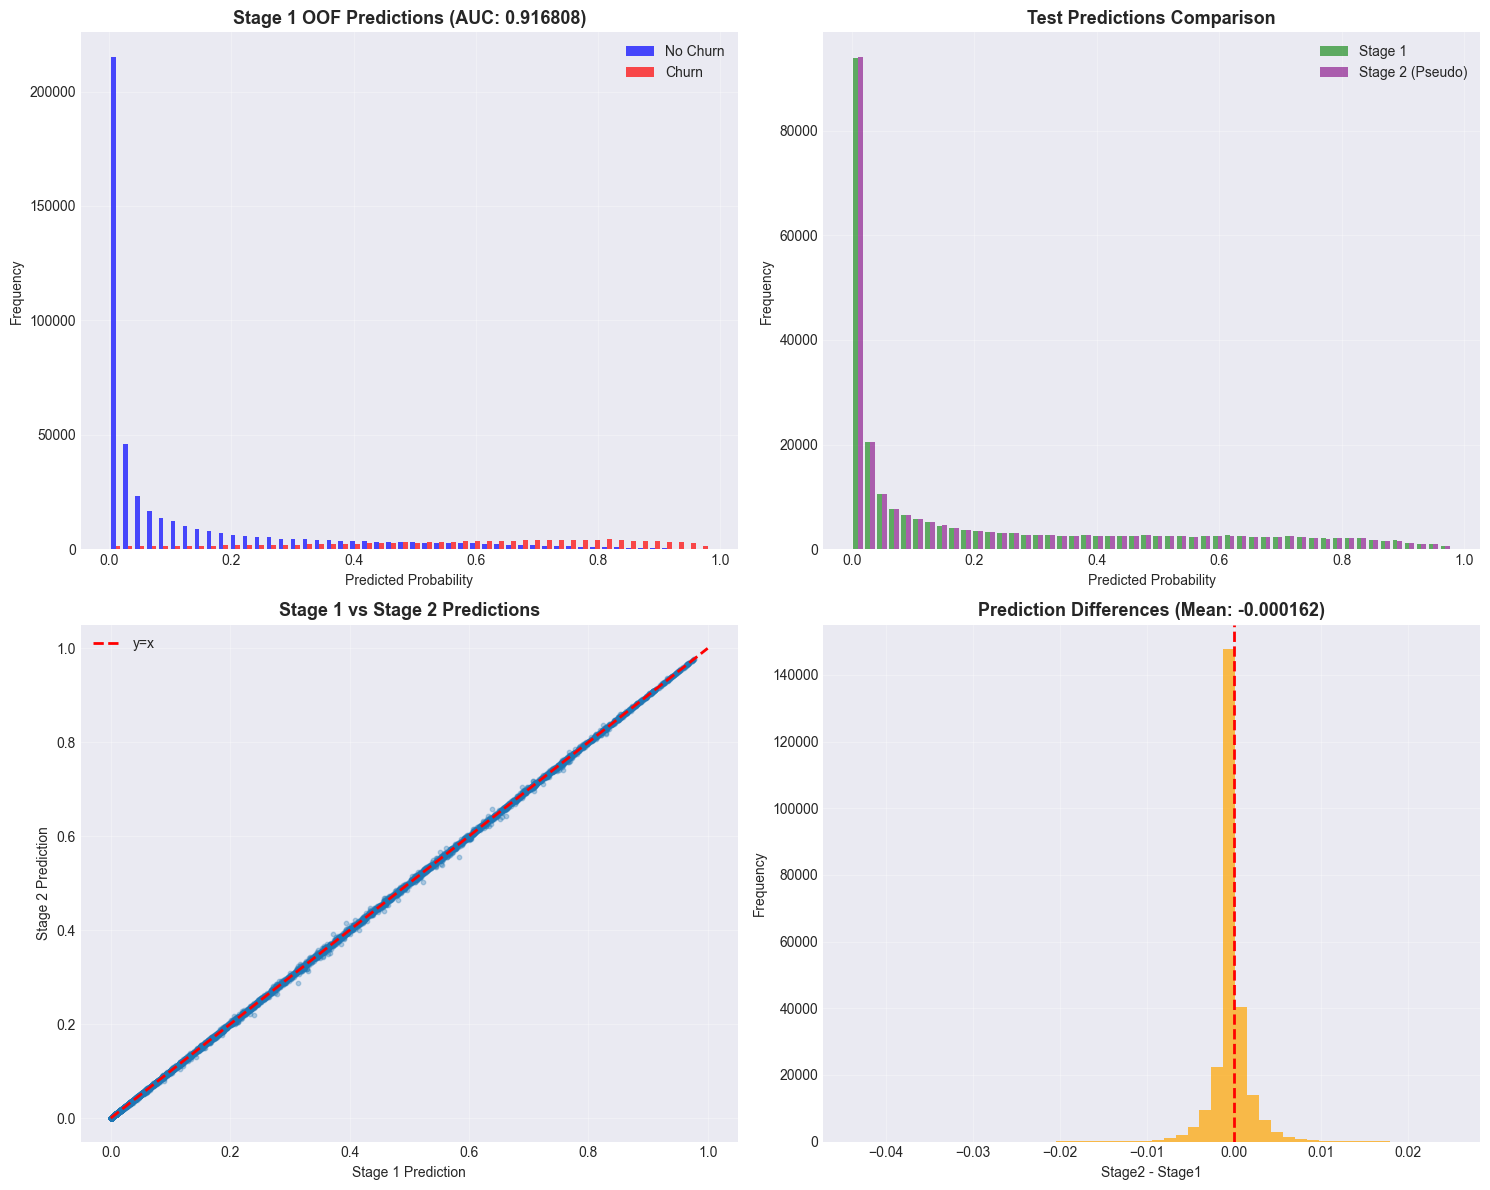

✅ Visualización guardada: predictions_analysis.png


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# OOF predictions (Stage 1)
axes[0, 0].hist([oof_lgb[y_train==0], oof_lgb[y_train==1]], bins=50,
                label=['No Churn', 'Churn'], alpha=0.7, color=['blue', 'red'])
axes[0, 0].set_title(f'Stage 1 OOF Predictions (AUC: {cv_auc:.6f})', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Predicted Probability')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Test predictions Stage 1 vs Stage 2
axes[0, 1].hist([pred_lgb, final_pred], bins=50, alpha=0.6,
                label=['Stage 1', 'Stage 2 (Pseudo)'], color=['green', 'purple'])
axes[0, 1].set_title('Test Predictions Comparison', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Predicted Probability')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Scatter Stage 1 vs Stage 2
sample_size = min(10000, len(final_pred))
indices = np.random.choice(len(final_pred), sample_size, replace=False)
axes[1, 0].scatter(pred_lgb[indices], final_pred[indices], alpha=0.3, s=10)
axes[1, 0].plot([0, 1], [0, 1], 'r--', linewidth=2, label='y=x')
axes[1, 0].set_title('Stage 1 vs Stage 2 Predictions', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Stage 1 Prediction')
axes[1, 0].set_ylabel('Stage 2 Prediction')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Diferencias
diff = final_pred - pred_lgb
axes[1, 1].hist(diff, bins=50, alpha=0.7, color='orange')
axes[1, 1].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1, 1].set_title(f'Prediction Differences (Mean: {diff.mean():.6f})', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Stage2 - Stage1')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('predictions_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Visualización guardada: predictions_analysis.png")

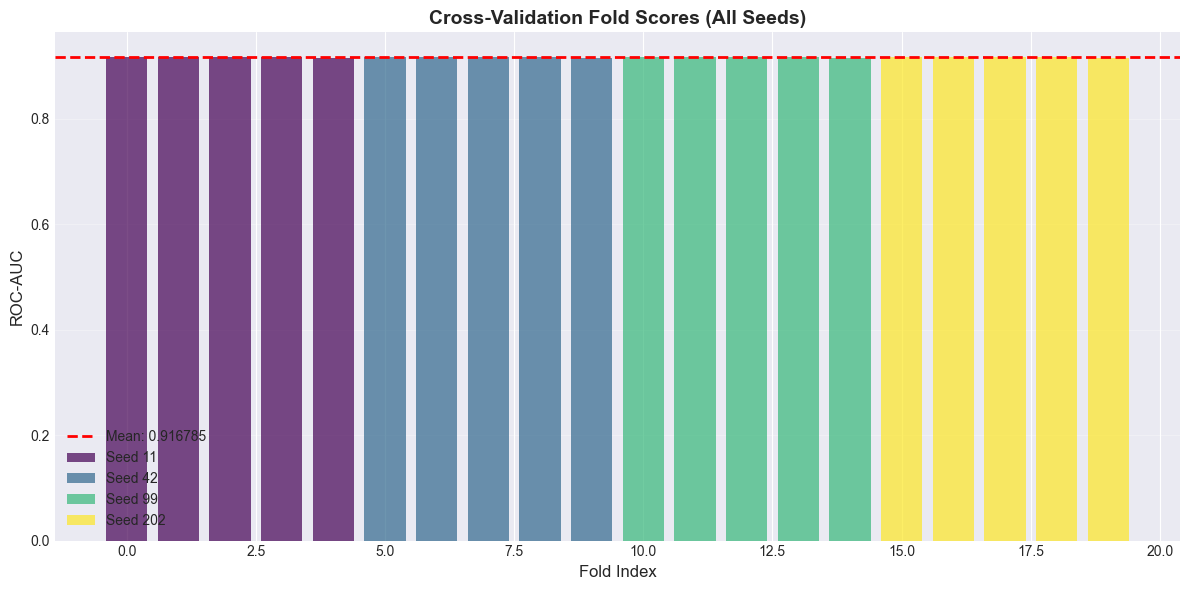

✅ Visualización guardada: cv_fold_scores_multiseed.png


In [18]:
# CV Fold scores
plt.figure(figsize=(12, 6))
x_pos = np.arange(len(all_fold_scores))
colors = plt.cm.viridis(np.linspace(0, 1, len(SEEDS)))

fold_scores_per_seed = [all_fold_scores[i:i+N_SPLITS] for i in range(0, len(all_fold_scores), N_SPLITS)]

for idx, (seed, scores) in enumerate(zip(SEEDS, fold_scores_per_seed)):
    offset = idx * N_SPLITS
    plt.bar(x_pos[offset:offset+N_SPLITS], scores, alpha=0.7,
            label=f'Seed {seed}', color=colors[idx])

plt.axhline(y=np.mean(all_fold_scores), color='r', linestyle='--', linewidth=2,
            label=f'Mean: {np.mean(all_fold_scores):.6f}')
plt.xlabel('Fold Index', fontsize=12)
plt.ylabel('ROC-AUC', fontsize=12)
plt.title('Cross-Validation Fold Scores (All Seeds)', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('cv_fold_scores_multiseed.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Visualización guardada: cv_fold_scores_multiseed.png")

In [19]:
# Entrenar modelo final para feature importance
print("\nEntrenando modelo final para feature importance...")
final_model = lgb.LGBMClassifier(**lgb_params)
final_model.fit(X_train, y_train, categorical_feature=cat_cols)

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 40 Features más importantes:")
print(feature_importance.head(40).to_string(index=False))

# Visualizar
plt.figure(figsize=(12, 16))
top_n = 50
top_features = feature_importance.head(top_n)

plt.barh(range(len(top_features)), top_features['importance'], color='steelblue')
plt.yticks(range(len(top_features)), top_features['feature'], fontsize=9)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title(f'Top {top_n} Most Important Features', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance_top50.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Visualización guardada: feature_importance_top50.png")


Entrenando modelo final para feature importance...


ValueError: pandas dtypes must be int, float or bool.
Fields with bad pandas dtypes: gender: object, Partner: object, Dependents: object, PhoneService: object, MultipleLines: object, InternetService: object, OnlineSecurity: object, OnlineBackup: object, DeviceProtection: object, TechSupport: object, StreamingTV: object, StreamingMovies: object, Contract: object, PaperlessBilling: object, PaymentMethod: object, tenure_bin: object, monthlycharges_bin: object, totalcharges_bin: object, Contract_x_PaymentMethod: object, Contract_x_InternetService: object, InternetService_x_OnlineSecurity: object, InternetService_x_TechSupport: object, PaymentMethod_x_PaperlessBilling: object, InternetService_x_StreamingTV: object, InternetService_x_StreamingMovies: object, Contract_x_TechSupport: object, gender_senior: object, partner_dependents: object, internet_payment: object, tenure_orig_bin: object, MonthlyCharges_orig_bin: object, TotalCharges_orig_bin: object

In [ ]:
total_time = optuna_time + stage1_time + stage2_time

print("\n" + "="*70)
print("RESUMEN FINAL - ADVANCED CHURN PREDICTION M3")
print("="*70)

print(f"\n🔥 HYPERPARAMETER TUNING (Optuna):")
print(f"   Trials: {len(study.trials)}")
print(f"   Mejor AUC en tuning: {study.best_value:.6f}")
print(f"   Tiempo: {optuna_time/60:.1f} min ({optuna_time/3600:.2f}h)")

print(f"\n📊 STAGE 1 (Multi-Seed sin Pseudo):")
print(f"   Seeds: {len(SEEDS)}")
print(f"   Folds: {N_SPLITS}")
print(f"   Modelos: {len(SEEDS) * N_SPLITS}")
print(f"   OOF AUC: {cv_auc:.6f}")
print(f"   CV Mean: {np.mean(all_fold_scores):.6f} ± {np.std(all_fold_scores):.6f}")
print(f"   Tiempo: {stage1_time/60:.1f} min ({stage1_time/3600:.2f}h)")

print(f"\n🎯 STAGE 2 (Pseudo-Labeling):")
print(f"   Pseudo-labels: {len(pseudo_X):,} ({pseudo_mask.mean()*100:.2f}%)")
print(f"   Peso: {PSEUDO_W}")
print(f"   Tiempo: {stage2_time/60:.1f} min ({stage2_time/3600:.2f}h)")

print(f"\n⏱️  TIEMPO TOTAL: {total_time/60:.1f} min ({total_time/3600:.2f}h)")

print(f"\n📁 ARCHIVOS GENERADOS:")
print(f"   ✓ submission_stage1_multiseed.csv  (OOF: {cv_auc:.6f})")
print(f"   ✓ submission_final_pseudo.csv      ← PRINCIPAL PARA KAGGLE")
print(f"   ✓ optuna_history_advanced.png")
print(f"   ✓ predictions_analysis.png")
print(f"   ✓ cv_fold_scores_multiseed.png")
print(f"   ✓ feature_importance_top50.png")

print(f"\n🎯 FEATURES TOTALES: {X_train.shape[1]}")
print(f"   Categóricas: {len(cat_cols)}")
print(f"   Numéricas:   {X_train.shape[1] - len(cat_cols)}")

print(f"\n🏆 SCORE ESPERADO EN KAGGLE:")
print(f"   Baseline (Stage 1): ~{cv_auc - 0.002:.3f} - {cv_auc + 0.001:.3f}")
print(f"   Con Pseudo-Label:   ~{cv_auc - 0.001:.3f} - {cv_auc + 0.002:.3f}")

print(f"\n💡 PRÓXIMOS PASOS:")
print(f"   1. Subir submission_stage1_multiseed.csv a Kaggle (baseline)")
print(f"   2. Subir submission_final_pseudo.csv a Kaggle")
print(f"   3. Si Stage 1 es mejor, ajustar PSEUDO_W o HI/LO thresholds")
print(f"   4. Considerar ensemble con otros modelos (CatBoost, XGBoost)")

print("\n" + "="*70)
print("✅ NOTEBOOK COMPLETADO - Listo para Kaggle!")
print("="*70)